<a href="https://colab.research.google.com/github/ag22042008/JEE-RANK-PREDICTOR/blob/main/JeeRankprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('/content/jee_marks_percentile_rank_2009_2026.csv')

In [3]:
df.shape

(1620, 5)

In [4]:
df.isnull().sum()

,0
Year,0
Marks,0
Percentile,0
Rank,0
Total_Candidates,0


In [5]:
df.duplicated().sum()

np.int64(0)

#Eda steps in this dataset

In [6]:
df['Year'].describe()

,Year
count,1620.000000
mean,2017.500000
std,5.189729
min,2009.000000
25%,2013.000000
50%,2017.500000
75%,2022.000000
max,2026.000000


In [7]:
df['Percentile'].describe()

,Percentile
count,1620.000000
mean,68.040127
std,34.111475
min,0.317587
25%,28.979665
50%,84.749529
75%,96.312400
max,100.000000


Text(0.5, 1.0, 'Boxplot of Percentiles')

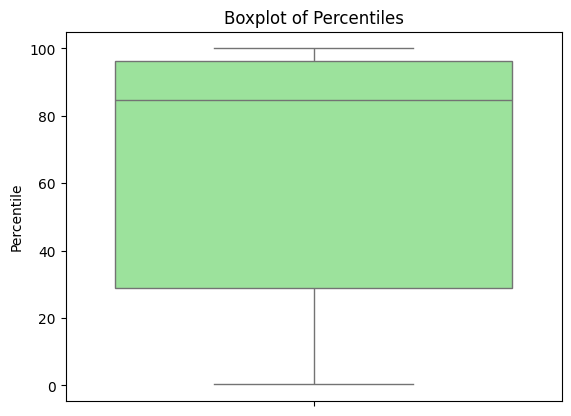

In [8]:

sns.boxplot(y=df['Percentile'], color='lightgreen')
plt.title('Boxplot of Percentiles')

In [9]:
import plotly.express as px



 Data is skewed toward high values

Median is closer to Q3 than Q1
Most values lie between 30 → 100
Big chunk of data is in high percentile range (80–100)

In [10]:
fig=px.histogram(df,x='Percentile',nbins=50)
fig.show()

In [11]:
df['Percentile'].skew()

np.float64(-0.8081668602357984)

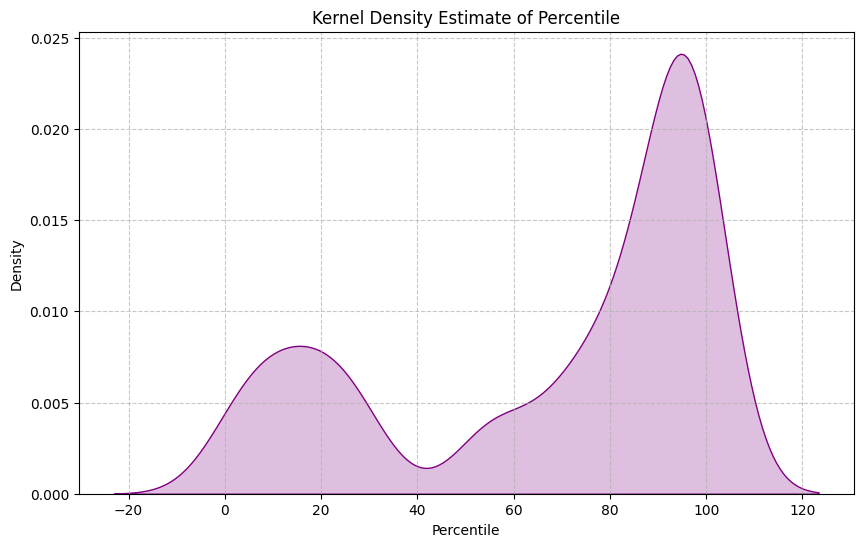

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Percentile', fill=True, color='purple')
plt.title('Kernel Density Estimate of Percentile')
plt.xlabel('Percentile')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
fig2=px.box(df,x='Percentile')
fig2.show()

Linear Regression is sensitive because it minimizes squared error globally, so extreme values (from skewness or outliers) disproportionately influence the model. Tree-based models like Decision Trees and XGBoost handle such values locally through splits, making them more robust.

In [14]:
fig2=px.box(df,x='Marks')
fig2.show()

Text(0.5, 1.0, 'Distribution of Marks')

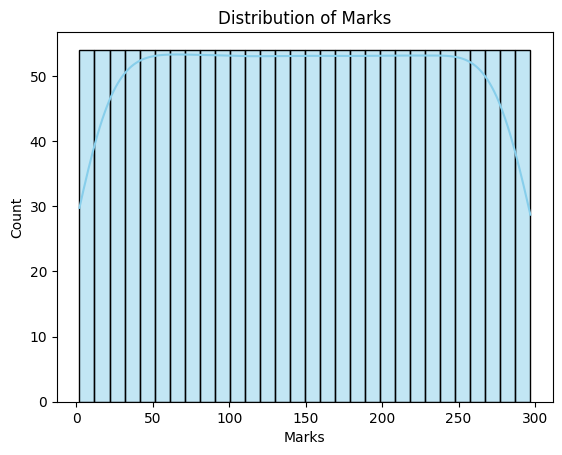

In [15]:
sns.histplot(df['Marks'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Marks')

#“Lack of distinction in KDE indicates high consistency in marks distribution across years.”

Year → categorical / discrete time
Marks → numerical

In [16]:
fig=px.box(df,x='Year',y='Marks')
fig.show()

For each year:

Width of violin
→ wider = more data density
→ thinner = less data
Middle line/box
→ shows median + quartiles
Shape
→ tells skewness / spread

In [17]:
import plotly.express as px

fig = px.violin(
    df,
    x="Year",
    y="Marks",
    box=True,        # shows box inside

    color="Year"     # color by year
)

fig.show()

In [18]:
df['Rank'].describe()

,Rank
count,1.620000e+03
mean,3.684445e+05
std,4.008154e+05
min,1.000000e+00
25%,4.491550e+04
50%,1.646180e+05
75%,6.721380e+05
max,1.379224e+06


<Axes: xlabel='Total_Candidates', ylabel='Density'>

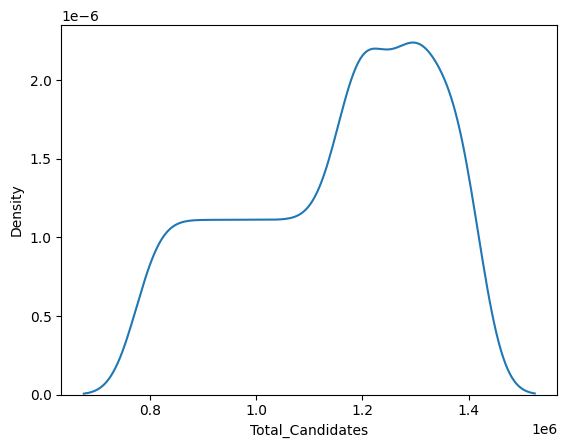

In [19]:
sns.kdeplot(data=df,x='Total_Candidates')

Primary Peak (Mode): The highest density is between 1.2 million and 1.4 million candidates. This suggests that for a large portion of the dataset (likely the most recent years), the candidate count has stabilized in this high range.

Secondary Peak/Shoulder: There is a smaller plateau or "shoulder" around 0.8 million to 1.0 million candidates, representing earlier years in the dataset when the number of aspirants was lower.

Competition Level: The density being heavily concentrated towards the right (higher values) indicates that the model you are building will be trained mostly on "high-competition" scenarios (over 1.2M students).

Consistency: The distinct peaks suggest there were specific periods where the candidate count remained relatively stable before jumping to a new level (likely due to policy changes or the merger of different exam phases).

In [20]:
df['Total_Candidates'].skew()

np.float64(-0.4499044877341955)

<Axes: xlabel='Rank', ylabel='Count'>

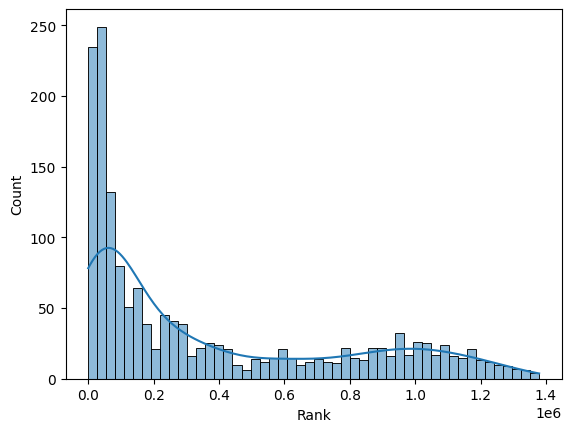

In [21]:
sns.histplot(df["Rank"], bins=50, kde=True)

#The rank variable exhibits a strong right-skewed distribution, where a large number of observations are concentrated in lower to mid-rank ranges, while the values extend over a wide range toward higher ranks, forming a long tail. The distribution is non-normal and heavy-tailed, indicating the presence of extreme values at the higher end. This suggests that rank is highly imbalanced and should be log-transformed or modeled using non-linear approaches for better performance.

In [22]:
df['Rank'].skew()

np.float64(0.9326328458687709)

#Bivariate Analysis

In [23]:
#rank with Total_Candidates

#1
More students = higher possible rank
As the number of candidates increases, the maximum rank also increases. Rank depends on how many people are giving the exam.
#2
More competition = bigger rank jumps
In years with more students, small differences in performance can lead to large changes in rank. So ranks become more spread out.
Each year has fixed candidates
#3
The data forms vertical lines because the number of candidates is fixed for each year. The gaps between lines show how registrations changed over time.

Rank depends on relative performance, not absolute marks

In [24]:
px.scatter(df,x='Total_Candidates',y='Rank')

#Rank depends on relative performance, not absolute marks

In [25]:
px.bar(df, x='Total_Candidates',y='Rank',color='Marks')

#Same marks improvement → bigger rank jump in higher competition

#The mapping between marks and rank is highly non-linear, with rank being more sensitive to score differences at higher marks due to lower candidate density.

Rank is not linearly dependent on marks—it is density-driven and becomes highly sensitive in the top-performing region.


#The plot shows a strong inverse relationship between marks and rank, with higher marks corresponding to better ranks. As the number of candidates increases, the rank range expands. The vertical clustering reflects fixed candidate counts per year, and the color gradient reveals a non-linear relationship where rank changes more sharply at higher marks and more gradually at lower marks.

# at same percentile there is different rank across each year due to increasing no of candidates

#Marks and rank have an inverse, non-linear relationship.
#Rank increases proportionally with total candidates,
#Rank can be approximately derived from percentile as a function of the candidate pool size

In [26]:
fig = px.scatter(df, x='Total_Candidates', y='Rank', title='Rank vs Total Candidates',color='Marks')
fig.update_xaxes(title_text='Total Candidates')
fig.update_yaxes(title_text='Rank')
fig.show()

In [27]:
fig = px.scatter(df, x='Rank', y='Marks', color='Percentile',
                 title='Rank vs Marks ',
                 labels={'Rank': 'Rank', 'Marks': 'Marks', 'Percentile': 'Percentile'},
                 )
fig.show()

As marks increase, rank improves, but not evenly. At high marks, small improvements drastically improve rank, while in the middle and lower ranges, even large mark increases result in small rank changes due to high student density.

df["log_rank"] = np.log1p(df["Rank"])

<Axes: >

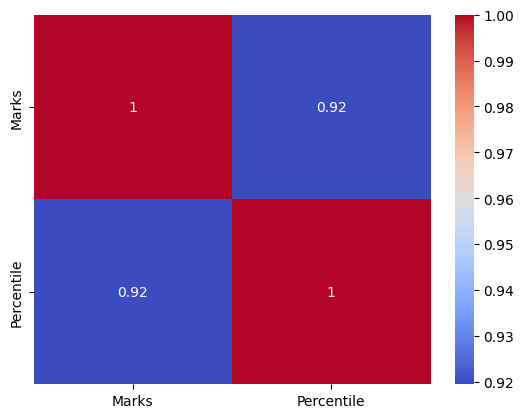

In [28]:
#correlation of two columns
sns.heatmap(df[['Marks','Percentile']].corr(),annot=True,cmap='coolwarm')#close correlation derived from percentile

In [29]:
df[['Marks','Percentile']].corr()

,Marks,Percentile
Marks,1.000000,0.919451
Percentile,0.919451,1.000000


#Multivariate Analysis

<Axes: >

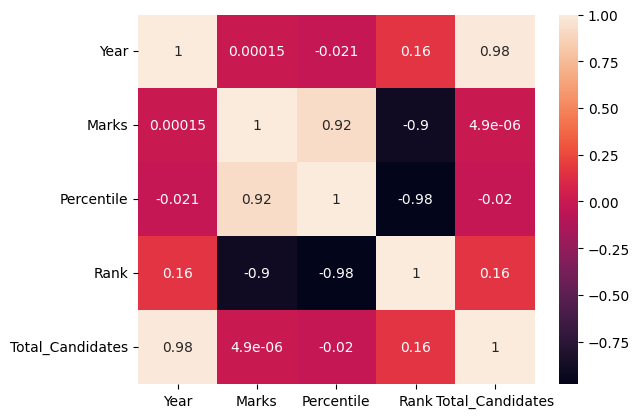

In [30]:
sns.heatmap(df.corr(),annot=True)

In [31]:
def rankRatio(dataframe):
  dataframe['RankRatio']=dataframe['Rank']/dataframe['Total_Candidates']
  return dataframe

In [32]:
df=rankRatio(df)


In [33]:
df

,Year,Marks,Percentile,Rank,Total_Candidates,RankRatio
0,2009,296,100.000000,1,800000,0.000001
1,2009,295,100.000000,1,800000,0.000001
2,2009,297,100.000000,1,800000,0.000001
3,2009,284,99.619975,3040,800000,0.003800
4,2009,284,100.000000,1,800000,0.000001
...,...,...,...,...,...,...
1615,2026,14,5.745426,1319564,1400000,0.942546
1616,2026,16,6.409149,1310271,1400000,0.935908
1617,2026,6,2.589523,1363746,1400000,0.974104
1618,2026,3,1.483988,1379224,1400000,0.985160


In [34]:
def get_category(ratio):
    if ratio <= 0.005:
        return 'Elite (Top 0.5%)'
    elif ratio <= 0.02:
        return 'Top Tier (0.5% - 2%)'
    elif ratio <= 0.05:
        return 'Highly Competitive (2% - 5%)'
    elif ratio <= 0.10:
        return 'Competitive (5% - 10%)'
    else:
        return 'Not Prepared (>10%)'


df['Category'] = df['RankRatio'].apply(get_category)



In [35]:
df

,Year,Marks,Percentile,Rank,Total_Candidates,RankRatio,Category
0,2009,296,100.000000,1,800000,0.000001,Elite (Top 0.5%)
1,2009,295,100.000000,1,800000,0.000001,Elite (Top 0.5%)
2,2009,297,100.000000,1,800000,0.000001,Elite (Top 0.5%)
3,2009,284,99.619975,3040,800000,0.003800,Elite (Top 0.5%)
4,2009,284,100.000000,1,800000,0.000001,Elite (Top 0.5%)
...,...,...,...,...,...,...,...
1615,2026,14,5.745426,1319564,1400000,0.942546,Not Prepared (>10%)
1616,2026,16,6.409149,1310271,1400000,0.935908,Not Prepared (>10%)
1617,2026,6,2.589523,1363746,1400000,0.974104,Not Prepared (>10%)
1618,2026,3,1.483988,1379224,1400000,0.985160,Not Prepared (>10%)


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [37]:
X=df.drop(['RankRatio','Category','Rank','Percentile'],axis=1)

In [38]:
Y= np.log1p(df["Rank"])

In [39]:
Y

,Rank
0,0.693147
1,0.693147
2,0.693147
3,8.019942
4,0.693147
...,...
1615,14.092813
1616,14.085745
1617,14.125747
1618,14.137032


In [40]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [41]:
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [42]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)

In [43]:
lr=LinearRegression()
X_train1=poly.fit_transform(X_train)
X_test1=poly.transform(X_test)
lr.fit(X_train1,Y_train)

LinearRegression()

In [44]:
y_lr_pred=lr.predict(X_test1)

In [45]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=300,max_depth=5, min_samples_split=3,
    min_samples_leaf=5,random_state=42)

In [46]:
rf.fit(X_train,Y_train)
y_rf_pred=rf.predict(X_test)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_lr_pred = np.expm1(y_lr_pred)
y_rf_pred = np.expm1(y_rf_pred)

In [48]:
y_test=np.expm1(Y_test)

In [49]:
r2_lr=r2_score(y_test,y_lr_pred)
r2_rf=r2_score(y_test,y_rf_pred)

In [50]:
r2_lr

0.9368199752918233

In [51]:
r2_lr
n = len(y_test)        # number of samples
p = X_test1.shape[1]    # number of features

adj_r2_lr= 1 - (1 - r2_lr) * (n - 1) / (n - p - 1)

In [52]:
adj_r2_lr


0.9326496766312176

In [53]:
r2_rf
n = len(y_test)        # number of samples
p = X_test.shape[1]    # number of features

adj_r2 = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)

In [54]:
r2_rf

0.992170581428536

In [55]:
r2_train = rf.score(X_train, (Y_train))
r2_test = rf.score(X_test, Y_test)

In [56]:
adj_r2

0.9920971806294285

In [57]:
r2_train

0.9449906238613405

In [58]:
r2_test

0.9838482001965296

In [59]:
all_preds = np.array([tree.predict(X_test) for tree in rf.estimators_])

95 percentile and 5 percentile ideal

🔥 So what was that “center + spread” thing?

Let me explain in simple words:

Step 1: Find average prediction
center = np.mean(all_preds)

👉 “Where most trees agree”

Step 2: Find how wide predictions are
spread = upper - lower

👉 “How much variation exists”

Step 3: Don’t use full width → shrink it
lower = center - 0.6 * spread
upper = center + 0.6 * spread

👉 Instead of using full noisy range
👉 we use 60% of it

In [60]:
lower = np.percentile(all_preds, 10, axis=0)
upper = np.percentile(all_preds, 90, axis=0)

In [61]:
lower_rank = np.expm1(lower)
upper_rank = np.expm1(upper)

In [62]:
coverage = np.mean((y_test >= lower_rank) & (y_test <= upper_rank))
print("Coverage:", coverage)

Coverage: 0.7160493827160493


In [63]:
range_width = upper_rank - lower_rank
print("Average Range Width:", range_width.mean())

Average Range Width: 65255.188597679895


In [64]:
mask = y_test < 100000

top_width = (upper_rank - lower_rank)[mask]
print("Top avg width:", top_width.mean())

Top avg width: 18030.289300205495


“I tried wider intervals like 5–95 but they became too large due to outlier trees, so I settled on 10–90 as a balance between coverage and usability.”

In [65]:
marks = float(input("Enter marks: "))
total_candidates = int(input("Enter total candidates: "))
year = int(input("Year "))
X_new=[[year,marks,total_candidates]]

Enter marks: 120
Enter total candidates: 2000000
Year 2012


In [66]:
X_new=[[year, marks, total_candidates]]
X_new=sc.transform(X_new)

In [67]:
rf_pred = rf.predict(X_new)[0]
rf_pred=np.expm1(rf_pred)

all_tree_preds = np.array([
    tree.predict(X_new)[0] for tree in rf.estimators_
])

rf_lower = np.percentile(all_tree_preds, 10)
rf_upper = np.percentile(all_tree_preds, 90)
rf_lower=np.expm1(rf_lower)
rf_upper=np.expm1(rf_upper)

In [68]:
print(f"Rank: {int(rf_pred)}")
print(f"RF Range: {int(rf_lower)} – {int(rf_upper)}")

Rank: 235374
RF Range: 173558 – 343370


In [69]:
X2=df.drop(columns=['Percentile','RankRatio','Category','Total_Candidates'])

In [70]:
Y2=df['Category']

In [71]:
Y2

,Category
0,Elite (Top 0.5%)
1,Elite (Top 0.5%)
2,Elite (Top 0.5%)
3,Elite (Top 0.5%)
4,Elite (Top 0.5%)
...,...
1615,Not Prepared (>10%)
1616,Not Prepared (>10%)
1617,Not Prepared (>10%)
1618,Not Prepared (>10%)


In [72]:
X2

,Year,Marks,Rank
0,2009,296,1
1,2009,295,1
2,2009,297,1
3,2009,284,3040
4,2009,284,1
...,...,...,...
1615,2026,14,1319564
1616,2026,16,1310271
1617,2026,6,1363746
1618,2026,3,1379224


In [73]:
from sklearn.preprocessing import LabelEncoder

In [74]:
encoder=LabelEncoder()
Y2=encoder.fit_transform(Y2)

In [75]:
X_train2,X_test2,Y_train2,Y_test2=train_test_split(X2,Y2,test_size=0.2,random_state=42)

In [76]:
from xgboost import XGBClassifier
model=XGBClassifier(n_estimators=200,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.8,random_state=42)

In [77]:
X_train2=sc.fit_transform(X_train2)
X_test2=sc.transform(X_test2)

In [78]:
model.fit(X_train2,Y_train2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [79]:
y_pred_clas=model.predict(X_test2)

In [80]:
from sklearn.metrics import accuracy_score

In [81]:
accuracy_score(Y_test2,y_pred_clas)

0.9722222222222222

In [82]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)

X_train2,y_train2=smote.fit_resample(X_train2,Y_train2)

In [83]:
model.fit(X_train2,y_train2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [84]:
y_pred_clas2=model.predict(X_test2)

In [85]:
accuracy_score(Y_test2,y_pred_clas2)

0.9691358024691358

In [86]:
model.score(X_train2,y_train2)

0.9927125506072875

In [87]:
from sklearn.metrics import classification_report
print(classification_report(Y_test2,y_pred_clas2))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       1.00      0.86      0.92         7
           2       0.92      0.98      0.95        57
           3       1.00      0.98      0.99       193
           4       0.94      1.00      0.97        34

    accuracy                           0.97       324
   macro avg       0.95      0.93      0.94       324
weighted avg       0.97      0.97      0.97       324



In [88]:
from sklearn.model_selection import cross_val_score

In [89]:
cv_scores=cross_val_score(model,X_train2,y_train2,cv=5)

In [90]:
cv_scores

array([0.98110661, 0.98785425, 0.98920378, 0.99190283, 0.99460189])

In [91]:
import numpy as np

y_shuffled = np.random.permutation(Y2)
y_shuffled

array([0, 0, 4, ..., 1, 3, 2])

In [92]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [93]:
from sklearn.svm import SVC
SVC=SVC(kernel='rbf', C=1, gamma='scale')

In [94]:
SVC.fit(X_train2,y_train2)

SVC(C=1)

In [95]:
Y_predict_svc=SVC.predict(X_test2)

In [96]:
accuracy_score(Y_test2,Y_predict_svc)

0.9290123456790124

In [97]:
print(classification_report(Y_test2,Y_predict_svc))

              precision    recall  f1-score   support

           0       0.80      0.97      0.88        33
           1       0.50      0.86      0.63         7
           2       0.96      0.89      0.93        57
           3       1.00      0.96      0.98       193
           4       0.79      0.79      0.79        34

    accuracy                           0.93       324
   macro avg       0.81      0.89      0.84       324
weighted avg       0.94      0.93      0.93       324



In [98]:
SVC.score(X_train2,y_train2)

0.9233468286099865

In [99]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=25,max_depth=4,min_samples_leaf=4,random_state=42)

In [100]:
model4=rf.fit(X_train2,y_train2)

In [101]:
y_predict_rf2=rf.predict(X_test2)

In [102]:
accuracy_score(y_predict_rf2,Y_test2)

0.9660493827160493

In [103]:
model4.score(X_train2,y_train2)

0.9595141700404858

In [104]:
from sklearn.model_selection import cross_val_score
cv_score5=cross_val_score(model4,X_train2,y_train2,cv=5)

In [105]:
cv_score5.mean()

np.float64(0.9686909581646423)

“The slightly lower training accuracy compared to test accuracy is due to regularization and the use of SMOTE, which introduces synthetic samples and makes the training data slightly more complex. This leads to better generalization.”